In [2]:
import glob
AML_files = glob.glob('./AML_scRNA-seq/*D0.h5ad')
print(AML_files)

['./AML_scRNA-seq/GSM3587989_AML916-D0.h5ad', './AML_scRNA-seq/GSM3587963_AML556-D0.h5ad', './AML_scRNA-seq/GSM3587931_AML328-D0.h5ad', './AML_scRNA-seq/GSM3587927_AML314-D0.h5ad', './AML_scRNA-seq/GSM3587985_AML870-D0.h5ad', './AML_scRNA-seq/GSM3587939_AML329-D0.h5ad', './AML_scRNA-seq/GSM3587993_AML997-D0.h5ad', './AML_scRNA-seq/GSM3587981_AML722B-D0.h5ad', './AML_scRNA-seq/GSM3587953_AML420B-D0.h5ad', './AML_scRNA-seq/GSM3587923_AML1012-D0.h5ad', './AML_scRNA-seq/GSM3587991_AML921A-D0.h5ad', './AML_scRNA-seq/GSM3587969_AML707B-D0.h5ad', './AML_scRNA-seq/GSM3587945_AML371-D0.h5ad', './AML_scRNA-seq/GSM3587951_AML419A-D0.h5ad', './AML_scRNA-seq/GSM3587925_AML210A-D0.h5ad', './AML_scRNA-seq/GSM3587959_AML475-D0.h5ad']


In [3]:
BM_files = glob.glob('./AML_scRNA-seq/*BM*.h5ad')
# BM_files = BM_files[1:]
print(BM_files)

['./AML_scRNA-seq/GSM3588003_BM5-34p38n.h5ad', './AML_scRNA-seq/GSM3588002_BM5-34p.h5ad', './AML_scRNA-seq/GSM3587999_BM3.h5ad', './AML_scRNA-seq/GSM3587996_BM1.h5ad', './AML_scRNA-seq/GSM3588000_BM4.h5ad', './AML_scRNA-seq/GSM3587997_BM2.h5ad']


In [4]:
import scanpy as sc
import anndata as ad
import pandas as pd
import numpy as np
import os
from scipy.sparse import csr_matrix
import warnings
warnings.filterwarnings('ignore')

# 设置环境
sc.settings.verbosity = 3
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor='white')

def integrate_h5ad_files(file_list, batch_labels=None):
    """
    整合多个h5ad文件并去除批次效应
    
    参数:
    file_list: h5ad文件路径列表
    batch_labels: 每个文件对应的批次标签列表
    keep: "all" 保留全部基因（并集），"top" 只保留前 top_n_genes 个基因
    top_n_genes: 当 keep="top" 时，保留的基因数量
    
    返回:
    整合后的AnnData对象
    """
    if batch_labels is None:
        batch_labels = [os.path.splitext(os.path.basename(f))[0] for f in file_list]
    assert len(file_list) == len(batch_labels), "文件数量和标签数量不一致"
    
    adatas = []
    for i, (file_path, label) in enumerate(zip(file_list, batch_labels)):
        print(f"正在处理文件 {i+1}/{len(file_list)}: {file_path}")
        adata = sc.read_h5ad(file_path)
        print(adata.X.shape)
        adata.obs['sample_label'] = label
        adata.obs['batch'] = str(i)
        if not isinstance(adata.X, csr_matrix):
            adata.X = csr_matrix(adata.X)
        adatas.append(adata)
    
    print("正在合并所有数据集...")
    # join='outer' → 保留并集基因
    integrated_adata = ad.concat(adatas, join='outer', label='batch_origin', index_unique='-')
    
    print("进行基本预处理...")
    sc.pp.filter_cells(integrated_adata, min_genes=200)
    sc.pp.filter_genes(integrated_adata, min_cells=3)
    integrated_adata.var['mt'] = integrated_adata.var_names.str.startswith('MT-')
    sc.pp.calculate_qc_metrics(integrated_adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)
    integrated_adata = integrated_adata[integrated_adata.obs['pct_counts_mt'] < 20, :]
    integrated_adata = integrated_adata[integrated_adata.obs['n_genes_by_counts'] < 6000, :]

    
    print("归一化数据...")
    sc.pp.normalize_total(integrated_adata, target_sum=1e4)
    sc.pp.log1p(integrated_adata)
    
    return integrated_adata


scanpy==1.10.3 anndata==0.8.0 umap==0.5.7 numpy==1.24.4 scipy==1.13.1 pandas==2.3.1 scikit-learn==1.6.1 statsmodels==0.14.4 igraph==0.10.8 pynndescent==0.5.13


In [5]:
import re
import pandas as pd
h5ad_files = AML_files + BM_files

AML_sample_labels = [label.split("-")[0].split("_")[1] for label in [file.split("/")[2] for file in AML_files]]  
BM_sample_labels = [re.search(r'(BM\d+)', path).group(1) for path in BM_files]
sample_labels = AML_sample_labels + BM_sample_labels

df = pd.read_excel('/disk1/cai029/Caufussion/Benchmark_driver/Ground_truths/AML_Summary_list.xlsx', engine='openpyxl')
driver_lst = df['gene_symbol'].tolist()
print("开始整合所有h5ad文件...")
integrated_adata = integrate_h5ad_files(h5ad_files, sample_labels)


print(f"原始数据细胞数: {integrated_adata.n_obs}")
not_nan_mask = ~integrated_adata.obs['CellType'].isna()

# 应用掩码过滤数据
integrated_adata= integrated_adata[not_nan_mask, :].copy()

print(f"过滤后细胞数: {integrated_adata.n_obs}")


开始整合所有h5ad文件...
正在处理文件 1/22: ./AML_scRNA-seq/GSM3587989_AML916-D0.h5ad
(933, 27899)
正在处理文件 2/22: ./AML_scRNA-seq/GSM3587963_AML556-D0.h5ad
(2328, 27899)
正在处理文件 3/22: ./AML_scRNA-seq/GSM3587931_AML328-D0.h5ad
(1094, 27899)
正在处理文件 4/22: ./AML_scRNA-seq/GSM3587927_AML314-D0.h5ad
(162, 27899)
正在处理文件 5/22: ./AML_scRNA-seq/GSM3587985_AML870-D0.h5ad
(345, 27899)
正在处理文件 6/22: ./AML_scRNA-seq/GSM3587939_AML329-D0.h5ad
(525, 27899)
正在处理文件 7/22: ./AML_scRNA-seq/GSM3587993_AML997-D0.h5ad
(83, 27899)
正在处理文件 8/22: ./AML_scRNA-seq/GSM3587981_AML722B-D0.h5ad
(79, 27899)
正在处理文件 9/22: ./AML_scRNA-seq/GSM3587953_AML420B-D0.h5ad
(485, 27899)
正在处理文件 10/22: ./AML_scRNA-seq/GSM3587923_AML1012-D0.h5ad
(1136, 27899)
正在处理文件 11/22: ./AML_scRNA-seq/GSM3587991_AML921A-D0.h5ad
(3813, 27899)
正在处理文件 12/22: ./AML_scRNA-seq/GSM3587969_AML707B-D0.h5ad
(1586, 27899)
正在处理文件 13/22: ./AML_scRNA-seq/GSM3587945_AML371-D0.h5ad
(756, 27899)
正在处理文件 14/22: ./AML_scRNA-seq/GSM3587951_AML419A-D0.h5ad
(1189, 27899)
正在处理文件 15/22: ./A

In [6]:
keep = 'all'
top_n_genes = 3001
driver_lst  = driver_lst 

if keep == "top":
    print(f"只保留前 {top_n_genes} 个基因...")
    sc.pp.highly_variable_genes(integrated_adata, n_top_genes=top_n_genes, batch_key='batch')
    integrated_adata.var['highly_variable'] = (
        integrated_adata.var['highly_variable'] | integrated_adata.var_names.isin(driver_lst)
    )
    integrated_adata = integrated_adata[:, integrated_adata.var['highly_variable']].copy()
    
else:
    print("保留所有基因，不做基因子集化")
    sc.pp.highly_variable_genes(integrated_adata, n_top_genes=2000, batch_key='batch')

print("使用Harmony进行批次校正...")
try:
    sc.tl.pca(integrated_adata, svd_solver='arpack')
    sc.external.pp.harmony_integrate(integrated_adata, key='batch', basis='X_pca', max_iter_harmony=20)
    sc.pp.neighbors(integrated_adata, use_rep='X_pca_harmony')
except ImportError:
    print("Harmony未安装，使用BBKNN进行批次校正...")
    sc.tl.pca(integrated_adata)
    sc.external.pp.bbknn(integrated_adata, batch_key='batch')

保留所有基因，不做基因子集化
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
使用Harmony进行批次校正...
computing PCA
    with n_comps=50
    finished (0:00:01)


2025-10-21 14:52:21,208 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-10-21 14:52:22,921 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-10-21 14:52:22,972 - harmonypy - INFO - Iteration 1 of 20
2025-10-21 14:52:26,232 - harmonypy - INFO - Iteration 2 of 20
2025-10-21 14:52:29,024 - harmonypy - INFO - Iteration 3 of 20
2025-10-21 14:52:31,714 - harmonypy - INFO - Iteration 4 of 20
2025-10-21 14:52:34,256 - harmonypy - INFO - Iteration 5 of 20
2025-10-21 14:52:37,072 - harmonypy - INFO - Converged after 5 iterations


computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:11)


In [7]:
integrated_adata

AnnData object with n_obs × n_vars = 22599 × 20718
    obs: 'NumberOfReads', 'AlignedToGenome', 'AlignedToTranscriptome', 'TranscriptomeUMIs', 'NumberOfGenes', 'CyclingScore', 'CyclingBinary', 'MutTranscripts', 'WtTranscripts', 'PredictionRF2', 'PredictionRefined', 'CellType', 'Score_HSC', 'Score_Prog', 'Score_GMP', 'Score_ProMono', 'Score_Mono', 'Score_cDC', 'Score_pDC', 'Score_earlyEry', 'Score_lateEry', 'Score_ProB', 'Score_B', 'Score_Plasma', 'Score_T', 'Score_CTL', 'Score_NK', 'sample_label', 'batch', 'NanoporeTranscripts', 'batch_origin', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'log1p', 'hvg', 'pca', 'neighbors'
    obsm: 'X_pca', 'X_pca_harmony'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:06)
running Leiden clustering
    finished: found 12 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:05)


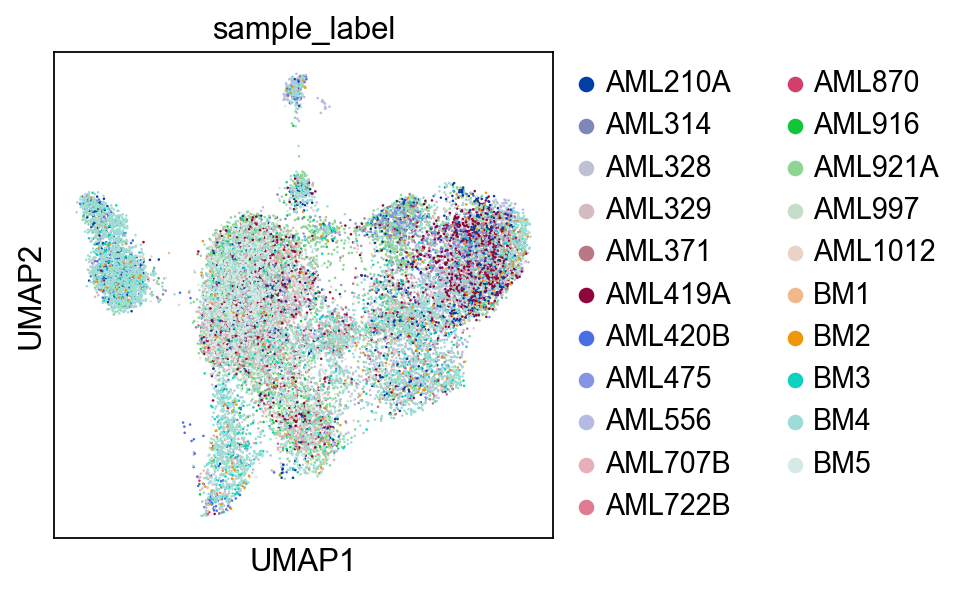

In [8]:
# print("进行UMAP降维...")
sc.tl.umap(integrated_adata)
sc.tl.leiden(integrated_adata,resolution=1.0)

sc.pl.umap(integrated_adata, color='sample_label')

In [10]:
# 保留不包含 "-like" 的细胞类型
# integrated_adata = integrated_adata[~integrated_adata.obs["CellType"].str.contains("-like")].copy()

In [7]:
integrated_adata.obs['CellType'] = integrated_adata.obs['CellType'].str.replace('-like$', '', regex=True)

In [8]:
batch_dict = {'A':'1','B':'0'}

In [9]:
integrated_adata.obs['stage'] = [int(batch_dict[batch[0]]) for batch in integrated_adata.obs_names.tolist()]

In [10]:
integrated_adata.write("./Dataset/all_data.h5ad")

In [1]:
sc.pl.umap(integrated_adata, color='CellType')

NameError: name 'sc' is not defined

In [40]:
# integrated_adata.obs['stage'] = [int(batch_dict[batch]) for batch in integrated_adata.obs['batch'].tolist()]

In [16]:
BM_adata = integrated_adata[integrated_adata.obs['stage'] == 0].copy()
AML_adata = integrated_adata[integrated_adata.obs['stage'] == 1].copy()

BM_adata.X = BM_adata.X.astype('float32')
AML_adata.X = AML_adata.X.astype('float32')

In [17]:
AML_adata.write("./Dataset/AML_data.h5ad")
BM_adata.write("./Dataset/BM_data.h5ad")

In [14]:
print("计算差异表达基因...")
sc.tl.rank_genes_groups(integrated_adata, groupby='leiden', method='wilcoxon')

计算差异表达基因...
ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:02)
